# LIBRARY

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
import numpy as np
from scipy.stats import gaussian_kde

In [28]:
file_path = "../1.DATASET/cmi_internet.csv"
df=pd.read_csv(file_path)
df.head(3)

,id,Basic_Demos-Enroll_Season,Basic_Demos-Age,Basic_Demos-Sex,CGAS-Season,CGAS-CGAS_Score,Physical-Season,Physical-BMI,Physical-Height,Physical-Weight,...,PCIAT-PCIAT_18,PCIAT-PCIAT_19,PCIAT-PCIAT_20,PCIAT-PCIAT_Total,SDS-Season,SDS-SDS_Total_Raw,SDS-SDS_Total_T,PreInt_EduHx-Season,PreInt_EduHx-computerinternet_hoursday,sii
0,0,Fall,5,0,Winter,51.0,Fall,16.877316,46.0,50.8,...,4.0,2.0,4.0,55.0,NaN,NaN,NaN,Fall,3.0,2.0
1,1,Summer,9,0,NaN,NaN,Fall,14.035590,48.0,46.0,...,0.0,0.0,0.0,0.0,Fall,46.0,64.0,Summer,0.0,0.0
2,2,Summer,10,1,Fall,71.0,Fall,16.648696,56.5,75.6,...,2.0,1.0,1.0,28.0,Fall,38.0,54.0,Summer,2.0,0.0


# Physical attributes

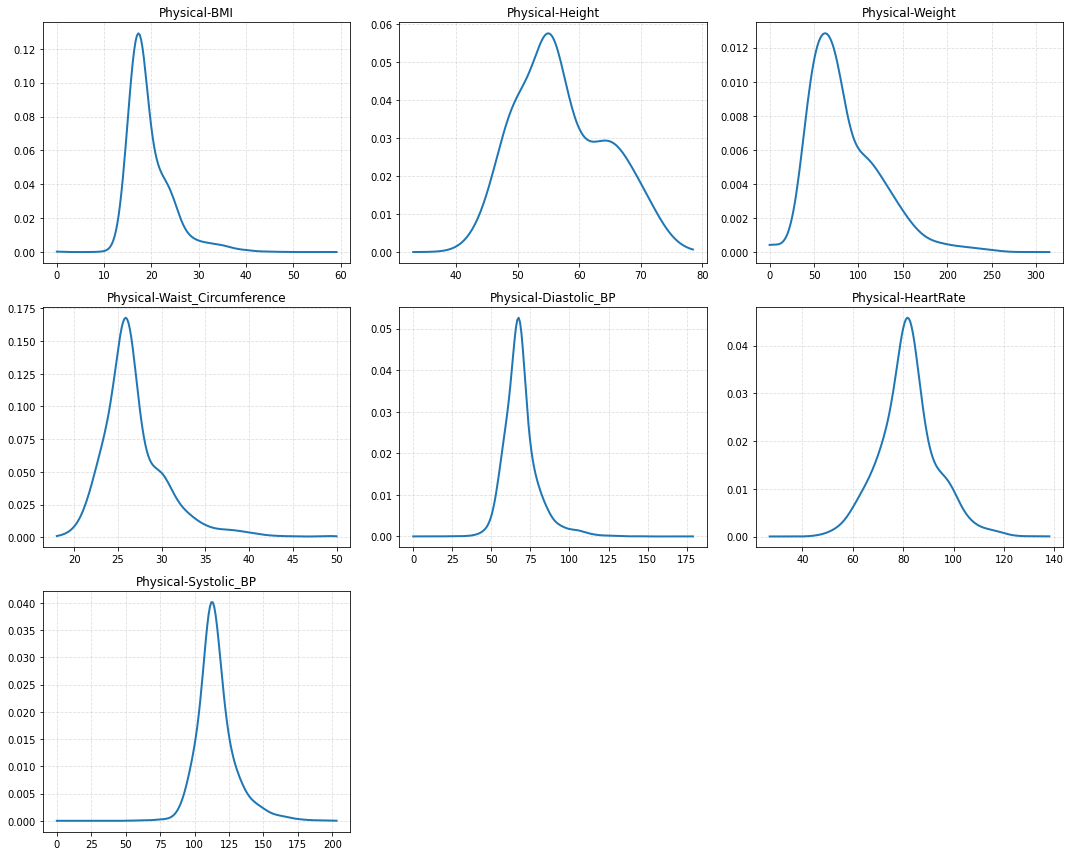

In [29]:
cols = [
    'Physical-BMI',
    'Physical-Height',
    'Physical-Weight',
    'Physical-Waist_Circumference',
    'Physical-Diastolic_BP',
    'Physical-HeartRate',
    'Physical-Systolic_BP'
]

fig, ax = plt.subplots(3, 3, figsize=(15, 12))
ax = ax.flatten()

for i, col in enumerate(cols):
    data = df[col].dropna().values
    kde = gaussian_kde(data, bw_method=0.3)

    x_vals = np.linspace(data.min(), data.max(), 200)

    ax[i].plot(x_vals, kde(x_vals), linewidth=2)
    ax[i].set_title(col)
    ax[i].grid(True, linestyle='--', alpha=0.4)

# rimuove i subplot vuoti (perché 9 spazi ma 7 variabili)
for j in range(len(cols), len(ax)):
    fig.delaxes(ax[j])

plt.tight_layout()
plt.show()

#from this I would say:
#physical height: we drop
# weight: has a similar shape to waist circumference, so drop weight and keep circumference
#diastolic and systolic have the same shape, so we can do something 
#heartrate: keep

# Max Stage vs time

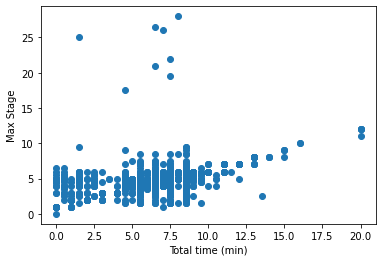

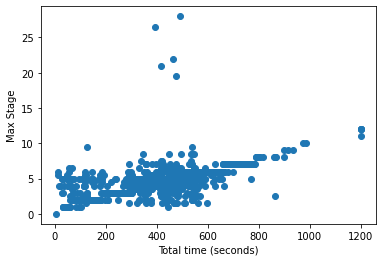

In [30]:
# this shows that the stage does not depend only on the time.
# probably we should keep the max stage bc it's more informative, since that for the same time we can have different stages

df["Fitness_Endurance_Time_Total"] = (
    df["Fitness_Endurance-Time_Mins"]*60 +
    df["Fitness_Endurance-Time_Sec"]
)

#some values disappear bc of missing values.

plt.scatter(df["Fitness_Endurance-Time_Mins"],
            df["Fitness_Endurance-Max_Stage"])

plt.xlabel("Total time (min)")
plt.ylabel("Max Stage")
plt.show()

plt.scatter(df["Fitness_Endurance_Time_Total"],
            df["Fitness_Endurance-Max_Stage"])

plt.xlabel("Total time (seconds)")
plt.ylabel("Max Stage")
plt.show()

# FGC vs Zone

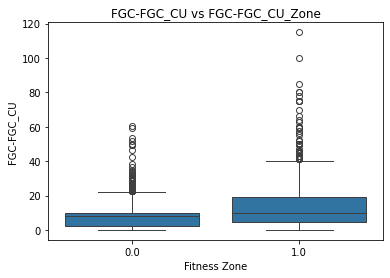

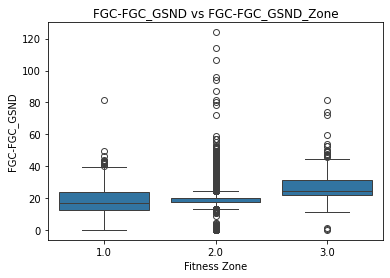

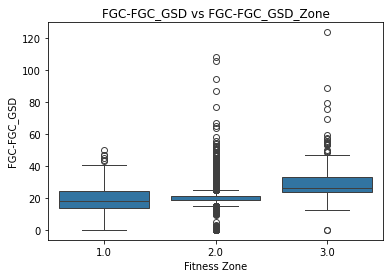

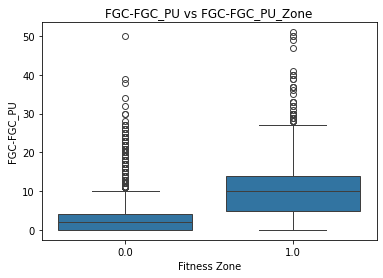

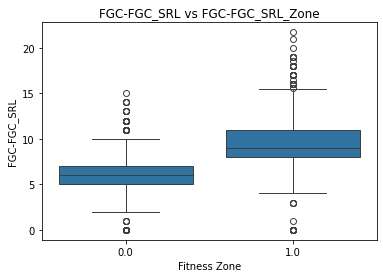

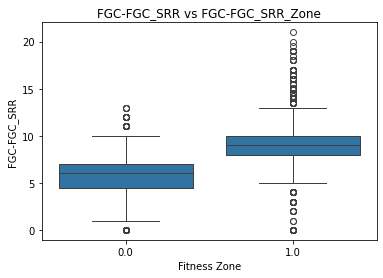

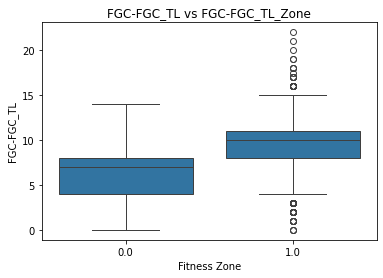

In [ ]:
# also here the score got in FGCs is not the only factor that determines the "fitness zone", since the margins of the zone overlap
# this time FGCs are more informative 
tests = [
    ("FGC-FGC_CU","FGC-FGC_CU_Zone"),
    ("FGC-FGC_GSND","FGC-FGC_GSND_Zone"),
    ("FGC-FGC_GSD","FGC-FGC_GSD_Zone"),
    ("FGC-FGC_PU","FGC-FGC_PU_Zone"),
    ("FGC-FGC_SRL","FGC-FGC_SRL_Zone"),
    ("FGC-FGC_SRR","FGC-FGC_SRR_Zone"),
    ("FGC-FGC_TL","FGC-FGC_TL_Zone")
]

for score, zone in tests:
    
    plt.figure(figsize=(6,4))
    
    sns.boxplot(x=df[zone], y=df[score])
    
    plt.xlabel("Fitness Zone")
    plt.ylabel(score)
    plt.title(f"{score} vs {zone}")
    
    plt.show()